# Opis

Notatnik służący do wizualizacji przestrzeni ukrytej autoenkoderów

In [1]:
IS_NEW_APPROACH = True
IS_VGAE = True

# Importy

In [2]:
%load_ext autoreload
%autoreload 2
import json
import matplotlib.pyplot as plt

import sys

sys.path.append('../')
import torch
from utils.FramsticksGraphDataset import FramsticksGraphDataset
from pyprojroot import here
from src.models.KlejdaGAE.KlejdaGraphAutoencoder import KlejdaGraphAutoencoder
from src.models.KlejdaGAE.KlejdaVariationalGraphAutoencoder import KlejdaVariationalGraphAutoencoder
from src.models.NewGAE.GraphAutoencoder import GraphAutoencoder
from src.models.NewGAE.VariationalGraphAutoencoder import VariationalGraphAutoencoder
import yaml
from torch.utils.data import Dataset, DataLoader, random_split

import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import kaleido
import plotly
import plotly.express as px
import pandas as pd
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.renderers.default = "notebook"
current_dir = os.getcwd()
framspy_path = os.path.abspath(os.path.join(current_dir, '..', 'external', 'framspy'))
if framspy_path not in sys.path:
	sys.path.insert(0, framspy_path)
with open("../configs/final_evolution_config.yaml", 'r') as f:
	evolution_config = yaml.safe_load(f)
with open("../configs/visualization_config.yaml", 'r') as f:
	config_vis = yaml.safe_load(f)

from FramsticksLib import FramsticksLib
import frams

frams.init(
	evolution_config['frams_path']
)
frams_lib = FramsticksLib(evolution_config['frams_path'], evolution_config['frams_lib'], evolution_config['sim_file'])

genotypes = []
with open("../results/sampled_best_individuals_new_mini_merged.jsonl", "r", encoding="utf-8") as f:
	for line in f:
		obj = json.loads(line.strip())
		genotypes.append(obj)
from src.deap.AutoencoderEvaluator import AutoencoderEvaluator




Using Framsticks version: 5.5
Home (writable) dir     : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data
Resources dir           : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data

Using Framsticks version: 5.5
Home (writable) dir     : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data
Resources dir           : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data

Available objects: ['CheckpointEvent', 'Collision', 'CrCollision', 'Creature', 'CreatureSettings', 'CreatureSignals', 'CreatureSnapshot', 'Dictionary', 'ExpProperties', 'ExpState', 'ExtValue', 'File', 'FunctionReference', 'GenMan', 'GenManStats', 'GenePool', 'GenePools', 'Geno', 'GenoConverters', 'Genotype', 'Interface', 'Joint', 'Loader', 'Math', 'MechJoint', 'MechPart', 'MessageCatcher', 'Model', 'ModelGeometry', 'ModelSymmetry', 'Neuro', 'NeuroClass', 'NeuroClassLibrary', 'NeuroDef', 'NeuroSignals', 'NeuronsSimEnabled', 'ODE', 'Orient', 'Part', 'P

# Przygotowanie autoenkodera

In [3]:
project_dir = here()
checkpoints_dir = project_dir / 'notebooks' / 'checkpoints' / 'final_checkpoints'

if IS_NEW_APPROACH:
	checkpoints_dir = checkpoints_dir / 'new'
else:
	checkpoints_dir = checkpoints_dir / 'klejda'
checkpoint_gae = torch.load(checkpoints_dir / 'gae.ckpt')
checkpoint_vgae = torch.load(checkpoints_dir / 'vgae.ckpt')
configs_dir = project_dir / 'configs'

if IS_NEW_APPROACH:
	config_gae_path = configs_dir / 'gae_config_large.yaml'
	config_vgae_path = configs_dir / 'gae_config_large.yaml'
else:
	config_gae_path = configs_dir / 'klejda_gae_config.yaml'
	config_vgae_path = configs_dir / 'klejda_gae_config.yaml'

with open(config_gae_path) as f:
	config_gae = yaml.safe_load(f)
with open(config_vgae_path) as f:
	config_vgae = yaml.safe_load(f)
torch.set_printoptions(precision=10)

## Przygotowanie macierzy wektorów ukrytych

In [4]:
NUMBER_OF_EXAMPLES = 1000

dataset = FramsticksGraphDataset(genotypes, config_gae["max_nodes"])
dataset_size = len(dataset)

dataloader = DataLoader(
	dataset,
	batch_size=1,
	shuffle=True,
	num_workers=2,
	persistent_workers=True
)

if IS_VGAE:
	if IS_NEW_APPROACH:
		autoencoder = VariationalGraphAutoencoder(config=config_vgae, frams_module=frams)
	else:
		autoencoder = KlejdaVariationalGraphAutoencoder(config=config_vgae, frams_module=frams)
	autoencoder.load_state_dict(checkpoint_vgae['state_dict'])
else:
	if IS_NEW_APPROACH:
		autoencoder = GraphAutoencoder(config=config_gae, frams_module=frams)
	else:
		autoencoder = KlejdaGraphAutoencoder(config=config_gae, frams_module=frams)
	autoencoder.load_state_dict(checkpoint_gae['state_dict'])

device = torch.device("cpu")
autoencoder = autoencoder.to(device)

autoencoder.eval()

latent_vectors = []
labels = []

with torch.no_grad():
	for i, batch in enumerate(dataloader):
		if i >= NUMBER_OF_EXAMPLES:
			break
		x_matrix = batch[0]
		a_matrix = batch[1]
		label = batch[2][config_gae['locality_loss_type']].squeeze(0).tolist()
		if config_gae['locality_loss_type'] == 'fitness':
			label = label[0]
		labels.append(label)
		z = autoencoder.encode(x_matrix, a_matrix)
		z_single = z.squeeze(0)

		latent_vectors.append(z_single)
latent_vectors = np.array(latent_vectors)
print(f"Pomyślnie wygenerowano {len(latent_vectors)} wektorów ukrytych.")
print(f"Kształt pojedynczego wektora z: {latent_vectors[0].shape}")

z_matrix = np.array(
	[z if isinstance(z, np.ndarray) else z.numpy() if isinstance(z, torch.Tensor) else z for z in latent_vectors])
labels_arr = np.array(labels)

pca3d = PCA(n_components=3)
pca3d.fit(z_matrix)
z_pca = pca3d.transform(z_matrix)
chosen_vector = z_matrix[10]

evaluator = AutoencoderEvaluator(autoencoder, frams_lib, evolution_config['opt_criteria'], evolution_config)

# --- Wspólna konfiguracja wizualizacji 3D ---
viz_cfg = dict(
	marker_size=5, marker_opacity=0.85, marker_line_width=1, marker_line_color='DarkSlateGrey',
	edge_width=8, edge_color='#7f8c8d',
	node_size=8, node_color='#1f77b4', node_line_color='white', node_line_width=2,
	ground_half_size=1.5, ground_color='#bdc3c7', ground_width=3,
	camera_eye=dict(x=1.6, y=1.6, z=0.1),
	scene_bgcolor='rgba(0,0,0,0)', paper_bgcolor='white', plot_bgcolor='white',
	title_font_size=20, title_x=0.5, annot_font_size=11, legend_font_color='black',
)


Pomyślnie wygenerowano 1000 wektorów ukrytych.
Kształt pojedynczego wektora z: (15,)


In [5]:
vis_legend_dict = dict(
	x=0.05,
	y=0.95,
	bgcolor='black',
	bordercolor='gray',
	borderwidth=1
)
cross_marker_dict = dict(size=3, color='red', symbol='x', opacity=0.9)

# Wizualizacja przestrzeni ukrytej

## PCA 2D

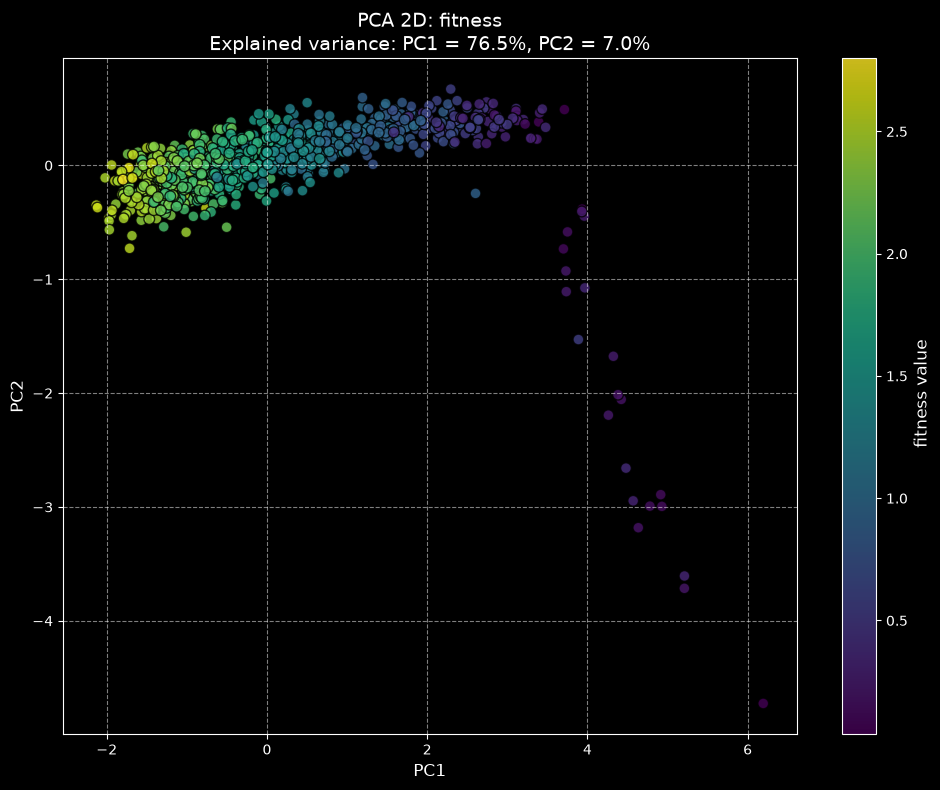

In [72]:
def visualize_pca_2d(labels, title):
	assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"

	pca = PCA(n_components=2)
	z_pca = pca.fit_transform(z_matrix)

	explained_variance = pca.explained_variance_ratio_ * 100

	plt.figure(figsize=(10, 8))

	scatter = plt.scatter(
		z_pca[:, 0],
		z_pca[:, 1],
		c=labels,
		cmap='viridis',
		marker='o',
		edgecolors='black',
		alpha=0.8,
		s=60
	)

	cbar = plt.colorbar(scatter)
	cbar.set_label(f' {config_gae['locality_loss_type']} value', fontsize=12)

	plt.title(f'{title}\nExplained variance: PC1 = {explained_variance[0]:.1f}%, PC2 = {explained_variance[1]:.1f}%',
			  fontsize=14)
	plt.xlabel(f'PC1', fontsize=12)
	plt.ylabel(f'PC2', fontsize=12)
	plt.grid(True, linestyle='--', alpha=0.5)
	plt.tight_layout()
	os.makedirs(config_vis['output_dir'], exist_ok=True)
	out_path = os.path.join(config_vis['output_dir'], "pca_2d")
	plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='black', transparent=False)

	plt.show()


visualize_pca_2d(labels_arr, title=f"PCA 2D: {config_gae['locality_loss_type']}")

## PCA 3D

In [6]:
def visualize_pca_3d_interactive(labels, title):
	assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"
	exp_var = pca3d.explained_variance_ratio_ * 100
	hover_texts = [f"Wartość: {lbl:.3f}" if isinstance(lbl, float) else f"Wartość: {lbl}" for lbl in labels]

	df = pd.DataFrame({
		'PC1': z_pca[:, 0],
		'PC2': z_pca[:, 1],
		'PC3': z_pca[:, 2],
		f'{config_gae['locality_loss_type']} value': labels,
		'Szczegóły': hover_texts
	})

	fig = px.scatter_3d(
		df,
		x='PC1',
		y='PC2',
		z='PC3',
		color=f'{config_gae['locality_loss_type']} value', hover_name='Szczegóły',
		title=f'{title}\n Explained variance: PC1 = {exp_var[0]:.1f}%, PC2 = {exp_var[1]:.1f}%, PC2 = {exp_var[2]:.1f}%',
		labels={
			'PC1': f'PC1 ({exp_var[0]:.1f}%)',
			'PC2': f'PC2 ({exp_var[1]:.1f}%)',
			'PC3': f'PC3 ({exp_var[2]:.1f}%)'
		},
		color_continuous_scale='Viridis', opacity=0.85
	)

	fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))
	fig.update_layout(width=900, height=800, margin=dict(t=40))
	save_for_paper(fig, "pca_3d", config_vis['output_dir'], "png", config_vis['scale'])
	fig.show()


visualize_pca_3d_interactive(labels_arr, title=f"PCA 3D: {config_gae['locality_loss_type']}")

# Generator struktury 3D pojedynczego osobnika

In [7]:
def get_plotly_traces(X, A, node_color=None, edge_color=None):
	x, y, z = X[:, 0], X[:, 1], X[:, 2]

	node_color = node_color or viz_cfg['node_color']
	edge_color = edge_color or viz_cfg['edge_color']

	edge_x, edge_y, edge_z = [], [], []
	n = A.shape[0]
	for i in range(n):
		for j in range(i + 1, n):
			if A[i, j] > 0.5:
				edge_x.extend([x[i], x[j], None])
				edge_y.extend([y[i], y[j], None])
				edge_z.extend([z[i], z[j], None])

	trace_edges = go.Scatter3d(
		x=edge_x, y=edge_y, z=edge_z,
		mode='lines',
		line=dict(color=edge_color, width=viz_cfg['edge_width']),
		hoverinfo='none', showlegend=False
	)

	trace_nodes = go.Scatter3d(
		x=x, y=y, z=z,
		mode='markers',
		marker=dict(
			size=viz_cfg['node_size'],
			color=node_color,
			line=dict(color=viz_cfg['node_line_color'], width=viz_cfg['node_line_width']),
			symbol='circle'
		),
		hoverinfo='none', showlegend=False
	)

	half_size = viz_cfg['ground_half_size']
	z_min = z.min()
	ground_z = z_min - 0.05
	gx = [-half_size, half_size, half_size, -half_size, -half_size]
	gy = [-half_size, -half_size, half_size, half_size, -half_size]
	gz = [ground_z, ground_z, ground_z, ground_z, ground_z]

	trace_ground = go.Scatter3d(
		x=gx, y=gy, z=gz,
		mode='lines',
		line=dict(color=viz_cfg['ground_color'], width=viz_cfg['ground_width']),
		hoverinfo='none', showlegend=False
	)

	return trace_edges, trace_nodes, trace_ground

# Wizualizacja grid search przykładowego osobnika

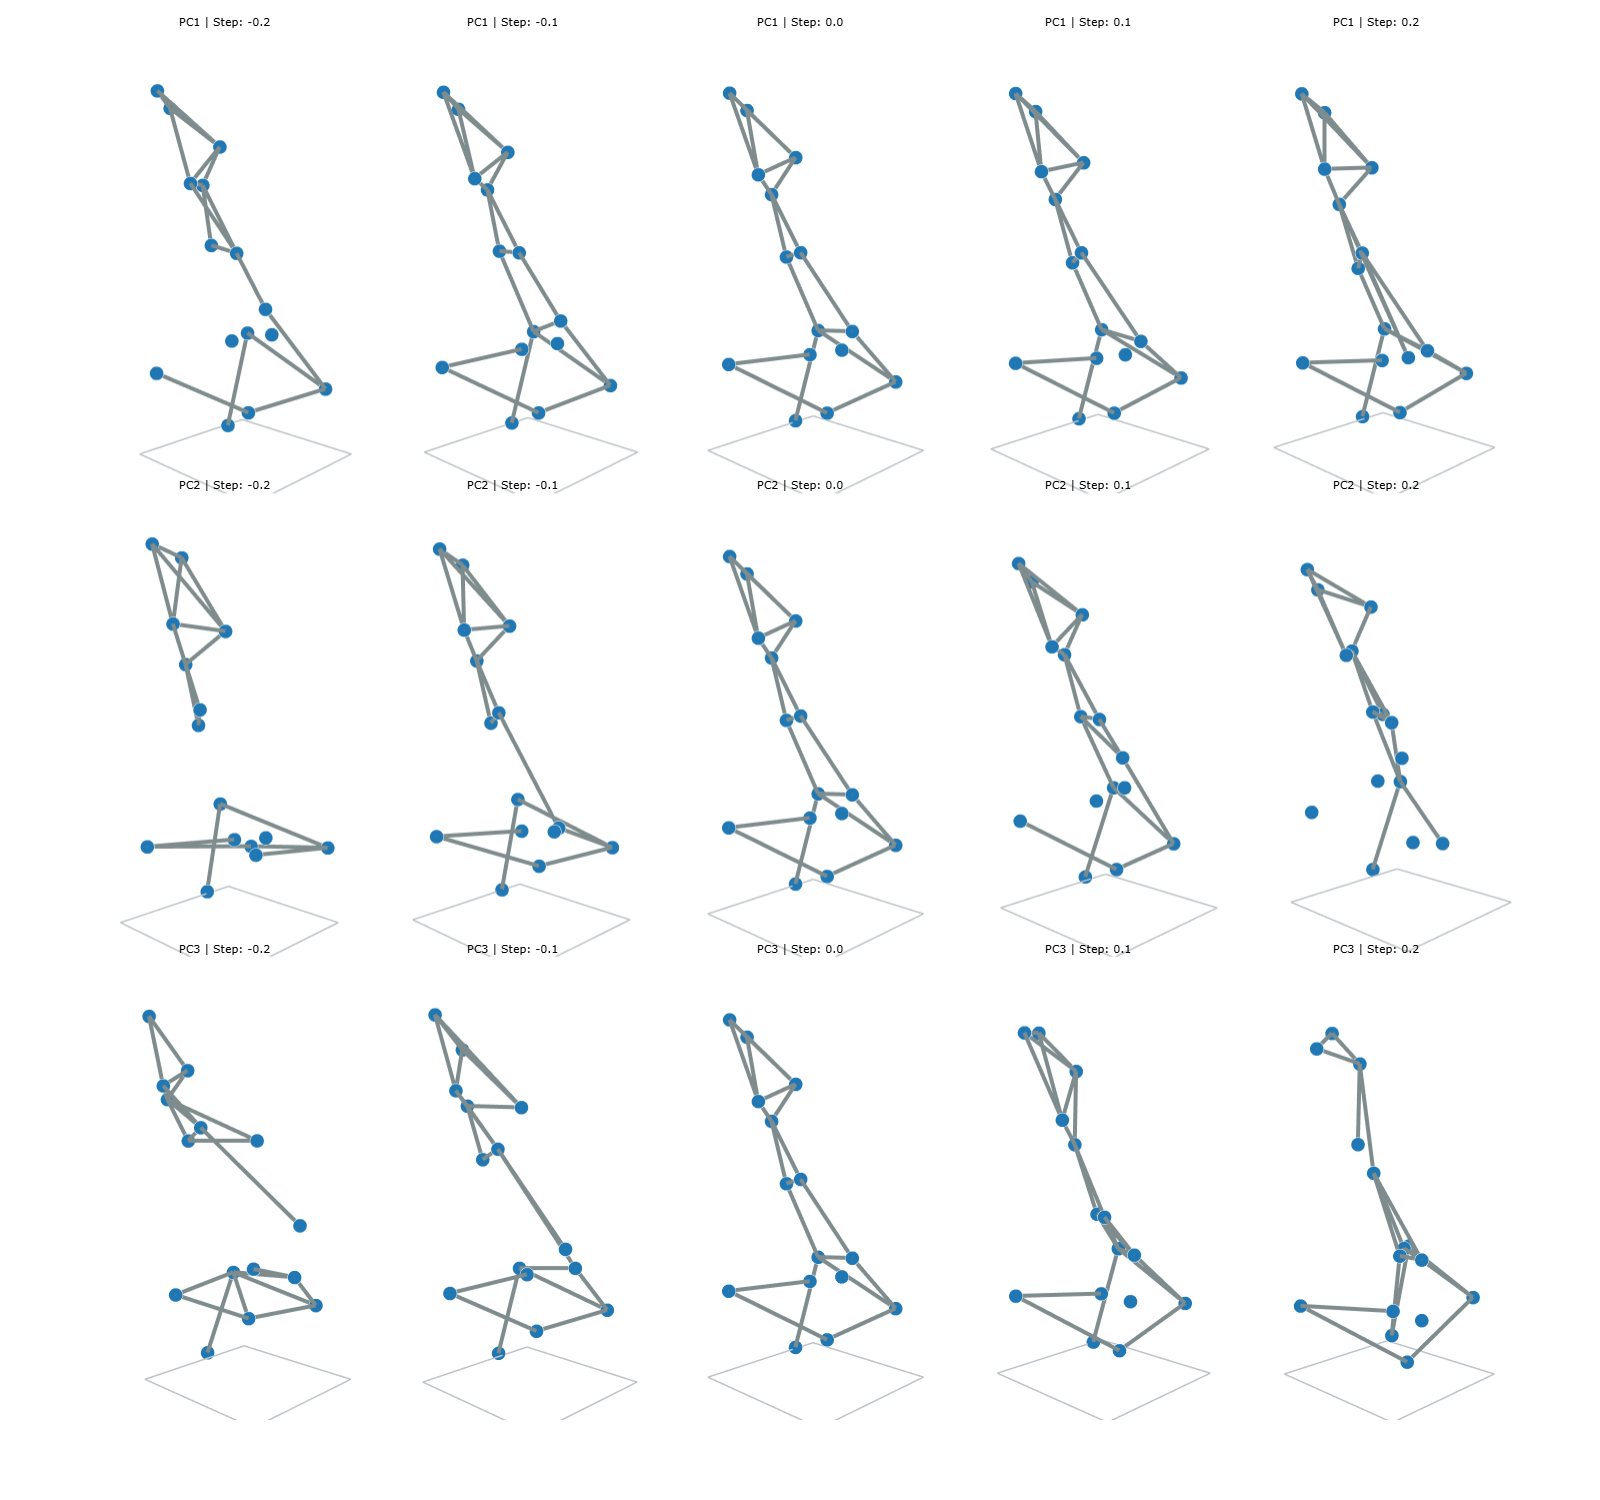

Zapisano: visualizations\pca_grid_search.png (skala: 2x)


In [8]:
def apply_scene_3d_defaults(fig):
	fig.update_scenes(
		xaxis_visible=False, yaxis_visible=False, zaxis_visible=False,
		xaxis=dict(showbackground=False, backgroundcolor=viz_cfg['scene_bgcolor']),
		yaxis=dict(showbackground=False, backgroundcolor=viz_cfg['scene_bgcolor']),
		zaxis=dict(showbackground=False, backgroundcolor=viz_cfg['scene_bgcolor']),
		camera=dict(eye=viz_cfg['camera_eye'])
	)


def apply_layout_defaults(fig, title_text, height=None, width=None):
	fig.update_layout(
		paper_bgcolor=viz_cfg['paper_bgcolor'],
		plot_bgcolor=viz_cfg['plot_bgcolor'],
		title=dict(text=title_text, x=viz_cfg['title_x'], font=dict(size=viz_cfg['title_font_size'])),
		margin=dict(t=30),
	)
	if height:
		fig.update_layout(height=height)
	if width:
		fig.update_layout(width=width)
	fig.update_annotations(font=dict(color='black', size=viz_cfg['annot_font_size']))


def save_for_paper(fig, filename_base, output_dir, fmt, scale):
	os.makedirs(output_dir, exist_ok=True)
	if fmt in ('png', 'both'):
		path_png = os.path.join(output_dir, f"{filename_base}.png")
		fig.write_image(path_png, scale=scale)
		print(f"Zapisano: {path_png} (skala: {scale}x)")
	if fmt in ('pdf', 'both'):
		path_pdf = os.path.join(output_dir, f"{filename_base}.pdf")
		fig.write_image(path_pdf)
		print(f"Zapisano: {path_pdf}")


def visualize_pca_grid_search_plotly(base_z, step_size=1.0, num_steps_side=3):
	alphas = np.linspace(-step_size * num_steps_side, step_size * num_steps_side, 2 * num_steps_side + 1)
	cols = len(alphas)
	rows = 3

	subplot_titles = [f"PC{r + 1} | Step: {alpha:.1f}" for r in range(rows) for alpha in alphas]

	fig = make_subplots(
		rows=rows, cols=cols,
		specs=[[{'type': 'scatter3d'} for _ in range(cols)] for _ in range(rows)],
		subplot_titles=subplot_titles,
		horizontal_spacing=0.000,
		vertical_spacing=0.000
	)

	directions = pca3d.components_[:3]
	autoencoder.eval()

	for pc_idx in range(rows):
		direction = directions[pc_idx]
		for step_idx, alpha in enumerate(alphas):
			z_new = base_z + alpha * direction
			z_tensor = torch.tensor(z_new, dtype=torch.float32).unsqueeze(0)

			with torch.no_grad():
				X_prime, A_prime = autoencoder.decode(z_tensor)

			X = X_prime.squeeze(0).numpy()
			A = A_prime.squeeze(0).numpy()

			trace_edges, trace_nodes, trace_ground = get_plotly_traces(X, A)

			row = pc_idx + 1
			col = step_idx + 1

			fig.add_trace(trace_edges, row=row, col=col)
			fig.add_trace(trace_nodes, row=row, col=col)
			fig.add_trace(trace_ground, row=row, col=col)

	apply_scene_3d_defaults(fig)
	apply_layout_defaults(fig, "", height=1500, width=1600)
	fig.show(renderer="png")
	save_for_paper(fig, "pca_grid_search", config_vis['output_dir'], "png", config_vis['scale'])


visualize_pca_grid_search_plotly(chosen_vector, 0.1, 2)

# Wizualizacja przejścia od najsłabszego do najlepszego rozwiązania (wraz z ekstrapolacją)

## Pomocnicze metody

In [9]:
def visualize_evolutionary_path_grid(path_vectors, num_of_extrapolated, fitnesses=None):
	num_steps = len(path_vectors)
	cols = 5
	rows = math.ceil(num_steps / cols)

	# 1. Obliczanie fitness w locie, jeśli nie podano gotowej listy, ale jest evaluator
	if fitnesses is None:
		fitnesses = []
		for v in path_vectors:
			v_np = v.detach().cpu().numpy().astype(np.float32) if isinstance(v, torch.Tensor) else np.asarray(v,
																											  dtype=np.float32)
			fit_tup, _, is_val, _, _ = evaluator(v_np)
			fitnesses.append(float(fit_tup[0]) if is_val else -1.0)

	# 2. Generowanie tytułów kafelków w formacie: "Krok | Fitness" lub "Krok | invalid"
	subplot_titles = []
	for idx in range(num_steps):
		step_num = idx + 1
		if fitnesses is not None:
			fit = fitnesses[idx]
			label = f"{step_num} | invalid" if fit < 0 else f"{step_num} | {fit:.2f}" if idx < num_steps - num_of_extrapolated else f"{step_num} | {fit:.2f} | ext"
		else:
			label = f"Step {step_num}"
		subplot_titles.append(label)

	# Uzupełnienie do pełnej siatki rows * cols pustymi stringami
	padded_titles = subplot_titles + [""] * (rows * cols - num_steps)

	# 3. Siatka wykresu
	specs = [[{'type': 'scatter3d'} for _ in range(cols)] for _ in range(rows)]
	fig = make_subplots(
		rows=rows, cols=cols,
		specs=specs,
		subplot_titles=padded_titles,
		horizontal_spacing=0.01,
		vertical_spacing=0.04
	)

	autoencoder.eval()

	for idx, z_vec in enumerate(path_vectors):
		if isinstance(z_vec, np.ndarray):
			z_tensor = torch.tensor(z_vec, dtype=torch.float32).unsqueeze(0)
		else:
			z_tensor = z_vec.clone().detach().type(torch.float32).unsqueeze(0)

		with torch.no_grad():
			X_prime, A_prime = autoencoder.decode(z_tensor)

		X = X_prime.squeeze(0).numpy()
		A = A_prime.squeeze(0).numpy()

		trace_edges, trace_nodes, trace_ground = get_plotly_traces(X, A)

		row = (idx // cols) + 1
		col = (idx % cols) + 1

		fig.add_trace(trace_ground, row=row, col=col)
		fig.add_trace(trace_edges, row=row, col=col)
		fig.add_trace(trace_nodes, row=row, col=col)

	apply_scene_3d_defaults(fig)
	camera = dict(eye=dict(x=1.3, y=1.3, z=1.2))

	for idx in range(num_steps):
		scene_name = "scene" if idx == 0 else f"scene{idx + 1}"
		fig.update_layout(**{f"{scene_name}_camera": camera})

	total_height = 350 * rows
	total_width = 1750

	apply_layout_defaults(
		fig,
		"",
		height=total_height,
		width=total_width
	)

	save_for_paper(fig, "2_evolution_path", config_vis['output_dir'], "png", config_vis['scale'])
	fig.show(renderer="png")

In [10]:
def visualize_evolutionary_path_in_pca(path_vectors, subplot_titles=None):
	z_pca_pop = pca3d.transform(z_matrix)
	exp_var = pca3d.explained_variance_ratio_ * 100

	hover_texts = [f"Fitness: {lbl:.3f}" if isinstance(lbl, float) else f"Fitness: {lbl}" for lbl in labels_arr]
	df_pop = pd.DataFrame({
		'PC1': z_pca_pop[:, 0],
		'PC2': z_pca_pop[:, 1],
		'PC3': z_pca_pop[:, 2],
		'Fitness': labels_arr,
		'Szczegóły': hover_texts
	})

	if isinstance(path_vectors, torch.Tensor):
		path_array = path_vectors.detach().numpy()
	elif isinstance(path_vectors, np.ndarray):
		path_array = path_vectors
	else:
		path_array = np.array(
			[v.detach().numpy() if isinstance(v, torch.Tensor) else np.array(v) for v in path_vectors])

	z_pca_path = pca3d.transform(path_array)
	num_points = path_array.shape[0]

	if subplot_titles is None or len(subplot_titles) != num_points:
		path_hover = [f"Step {i + 1}" for i in range(num_points)]
	else:
		path_hover = subplot_titles

	fig = go.Figure()

	fig.add_trace(go.Scatter3d(
		x=df_pop['PC1'], y=df_pop['PC2'], z=df_pop['PC3'],
		mode='markers',
		marker=dict(
			size=viz_cfg['marker_size'],
			color=df_pop['Fitness'],
			colorscale='Viridis',
			opacity=0.4,
			colorbar=dict(title=dict(
				text="Fitness",
				font=dict(color='black')
			), tickfont=dict(color='black'))
		),
		text=df_pop['Szczegóły'],
		hoverinfo='text',
		name='Individuals'
	))

	fig.add_trace(go.Scatter3d(
		x=z_pca_path[:, 0], y=z_pca_path[:, 1], z=z_pca_path[:, 2],
		mode='lines+markers',
		line=dict(color='red', width=6),
		marker=dict(size=4, color='gray', symbol='diamond'),
		text=path_hover,
		hoverinfo='text',
		name='Evolution path'
	))

	fig.update_layout(
		width=900,
		height=800,
		title=dict(
			text=f'Evolution path',
			x=0.5,
			font=dict(size=16, color='black')
		),
		scene=dict(
			aspectmode='cube',
			xaxis=dict(
				title=dict(text=f'PC1 ({exp_var[0]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='black')
			),
			yaxis=dict(
				title=dict(text=f'PC2 ({exp_var[1]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='black')
			),
			zaxis=dict(
				title=dict(text=f'PC3 ({exp_var[2]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='black')
			)
		),
		paper_bgcolor=viz_cfg['paper_bgcolor'],
		plot_bgcolor=viz_cfg['plot_bgcolor'],
		margin=dict(l=0, r=0, b=0, t=50),
		legend=vis_legend_dict
	)
	save_for_paper(fig, "2_evolution_path_pca", config_vis['output_dir'], "png", config_vis['scale'])
	fig.show()

Poniższy kod dzieli próbkę osobników i ich wektorów w przestrzeni latentnej na kubełki, wylicza średnią wartość każdego kubełka, tworząc reprezentantów każdego fitness. Zebrane średnie wektory przestrzeni latentnej wykorzystywane są do wizualizacji przejścia przez te wektory. Można dobrać interesujący zakres

In [11]:
fitness_min = 0.0
fitness_max = 39.0

mask = (labels_arr >= fitness_min) & (labels_arr <= fitness_max)
z_matrix = z_matrix[mask]
labels_arr = labels_arr[mask]

if len(labels_arr) == 0:
	raise ValueError("Brak osobników spełniających kryteria wybranego zakresu fitness!")

sorted_indices = np.argsort(labels_arr)
sorted_z = z_matrix[sorted_indices]
sorted_fitness = labels_arr[sorted_indices]

num_bins = min(10, len(sorted_z))
chunks = np.array_split(np.arange(len(sorted_z)), num_bins)

bin_vectors = []
bin_fitnesses = []
subplot_titles = []

for i, chunk in enumerate(chunks):
	if len(chunk) > 0:
		mean_z = np.mean(sorted_z[chunk], axis=0)
		mean_fit = np.mean(sorted_fitness[chunk])
		bin_vectors.append(mean_z)
		bin_fitnesses.append(mean_fit)
		subplot_titles.append(f"Kubełek {i + 1}\nFit: {mean_fit:.2f}")

bin_vectors = np.array(bin_vectors)

path_vectors = list(bin_vectors)
num_extrap_steps = 3

if len(bin_vectors) >= 2:
	window_size = min(5, len(bin_vectors))
	recent_bins = bin_vectors[-window_size:]
	trend_vector = np.mean(np.diff(recent_bins, axis=0), axis=0)

	for step in range(1, num_extrap_steps + 1):
		extrap_z = bin_vectors[-1] + step * trend_vector
		path_vectors.append(extrap_z)
		subplot_titles.append(f"Ekstrap. +{step}\n(Trend)")

path_vectors = np.array(path_vectors)
print(f"Liczba punktów w path_vectors: {len(path_vectors)}")

Liczba punktów w path_vectors: 13


## Wizualizacja osobników na ścieżce

C:\Users\witek\PycharmProjects\Magisterka\notebooks\..\src\deap\AutoencoderEvaluator.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  latent_vector = torch.tensor([individual], dtype=torch.float32)


Zapisano: visualizations\2_evolution_path.png (skala: 2x)


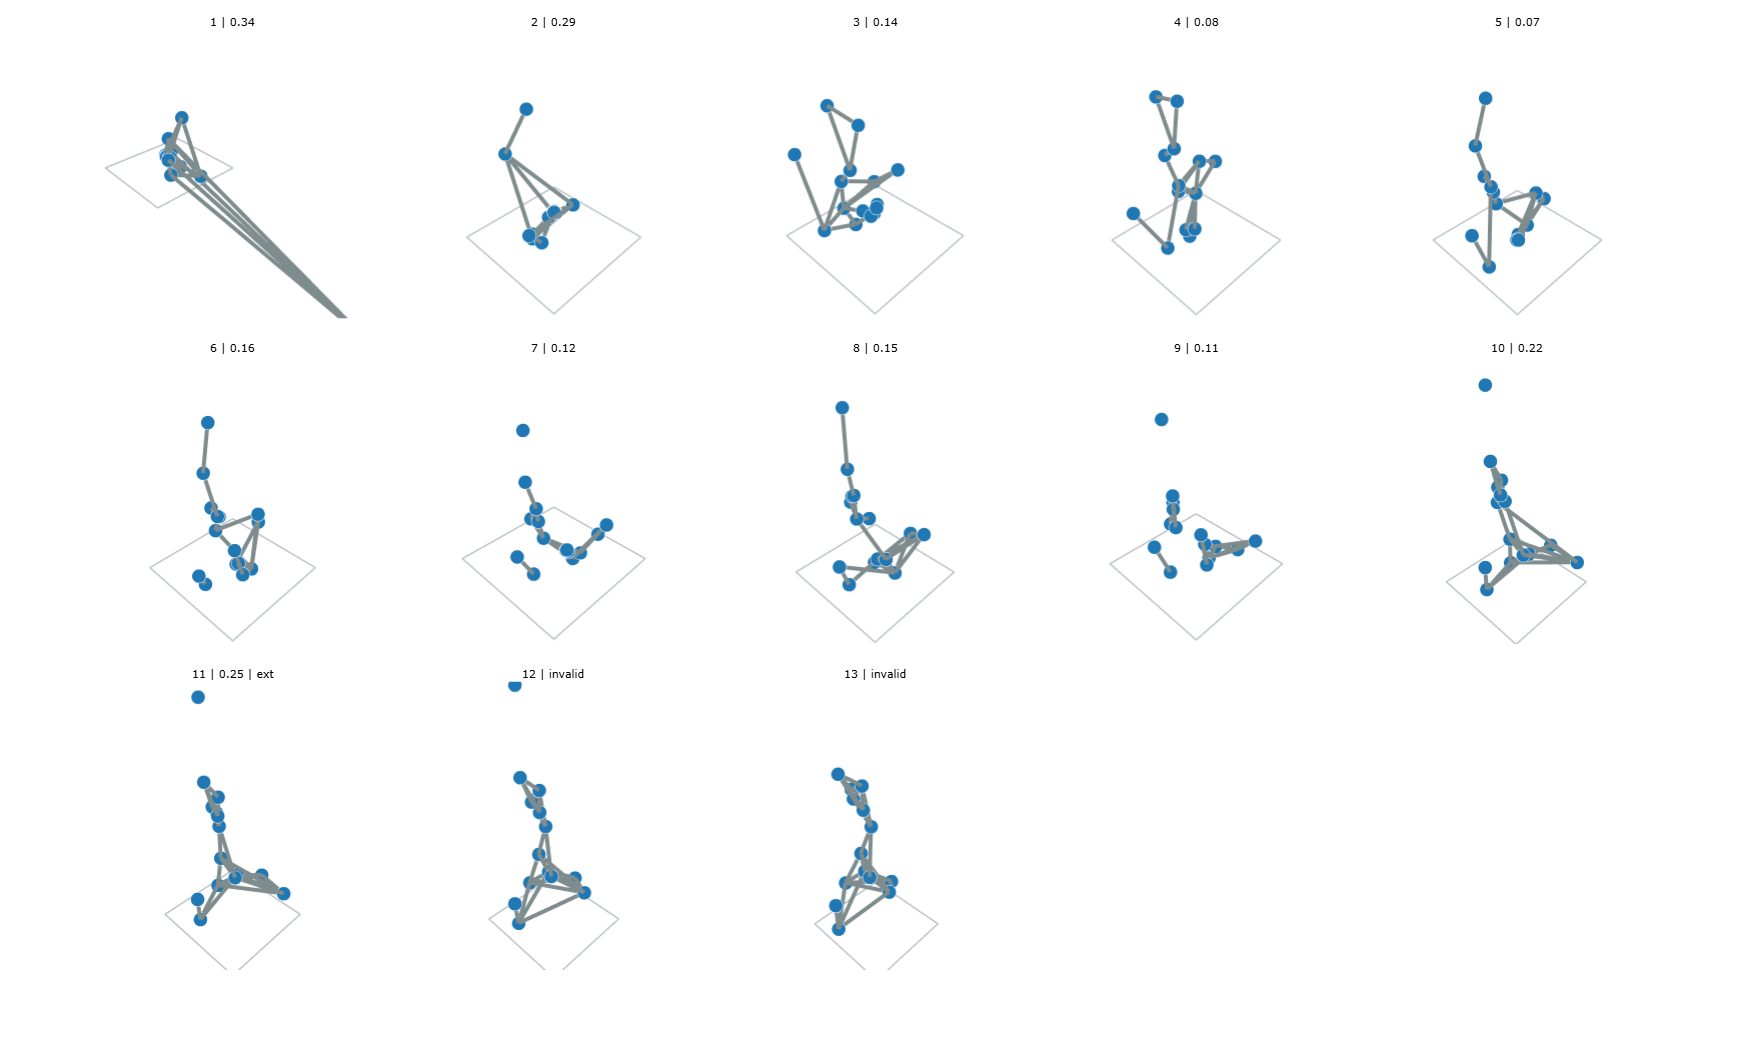

In [12]:
visualize_evolutionary_path_grid(path_vectors, num_extrap_steps)

## Wizualizacja ścieżki w przestrzeni ukrytej

In [13]:
visualize_evolutionary_path_in_pca(path_vectors)

# Wizualizacja otoczenia danych wartości przestrzeni ukrytej

In [14]:
def visualize_latent_grid_search_plotly(
		base_z,
		step_size,
		num_steps_side
):
	if isinstance(base_z, torch.Tensor):
		base_z_np = base_z.detach().cpu().numpy().astype(np.float32).flatten()
	else:
		base_z_np = np.asarray(base_z, dtype=np.float32).flatten()

	latent_dim = len(base_z_np)
	dim_indices = list(range(latent_dim))

	alphas = np.linspace(-step_size * num_steps_side, step_size * num_steps_side, 2 * num_steps_side + 1)
	cols = len(alphas)
	rows = len(dim_indices)

	autoencoder.eval()

	subplot_titles = []
	generated_data = []

	for row_idx, d in enumerate(dim_indices):
		direction = np.zeros_like(base_z_np)
		direction[d] = 1.0

		for step_idx, alpha in enumerate(alphas):
			z_new = (base_z_np + alpha * direction).astype(np.float32)

			fitness_tuple, _, is_valid_ind, _, _ = evaluator(z_new)
			fit_val = float(fitness_tuple[0]) if is_valid_ind else -1.0

			if fit_val < 0:
				fit_str = "invalid"
			else:
				fit_str = f"{fit_val:.2f}"

			title = f"Dim {d} | Step: {alpha:.2f} | Fitness: {fit_str}"
			subplot_titles.append(title)

			generated_data.append((z_new, row_idx + 1, step_idx + 1))

	fig = make_subplots(
		rows=rows, cols=cols,
		specs=[[{'type': 'scatter3d'} for _ in range(cols)] for _ in range(rows)],
		subplot_titles=subplot_titles,
		horizontal_spacing=0.01,
		vertical_spacing=0.03
	)

	for z_new, row, col in generated_data:
		z_tensor = torch.tensor(z_new, dtype=torch.float32).unsqueeze(0)

		with torch.no_grad():
			X_prime, A_prime = autoencoder.decode(z_tensor)

		X = X_prime.squeeze(0).numpy()
		A = A_prime.squeeze(0).numpy()

		trace_edges, trace_nodes, trace_ground = get_plotly_traces(X, A)

		fig.add_trace(trace_ground, row=row, col=col)
		fig.add_trace(trace_edges, row=row, col=col)
		fig.add_trace(trace_nodes, row=row, col=col)

	apply_scene_3d_defaults(fig)

	total_height = max(600, 300 * rows)
	total_width = min(2500, max(1200, 250 * cols))

	apply_layout_defaults(
		fig,
		"",
		height=total_height,
		width=total_width
	)

	save_for_paper(fig, "3_latent_grid_search", config_vis['output_dir'], "png", config_vis['scale'])
	fig.show(renderer='png')

Zapisano: visualizations\3_latent_grid_search.png (skala: 2x)


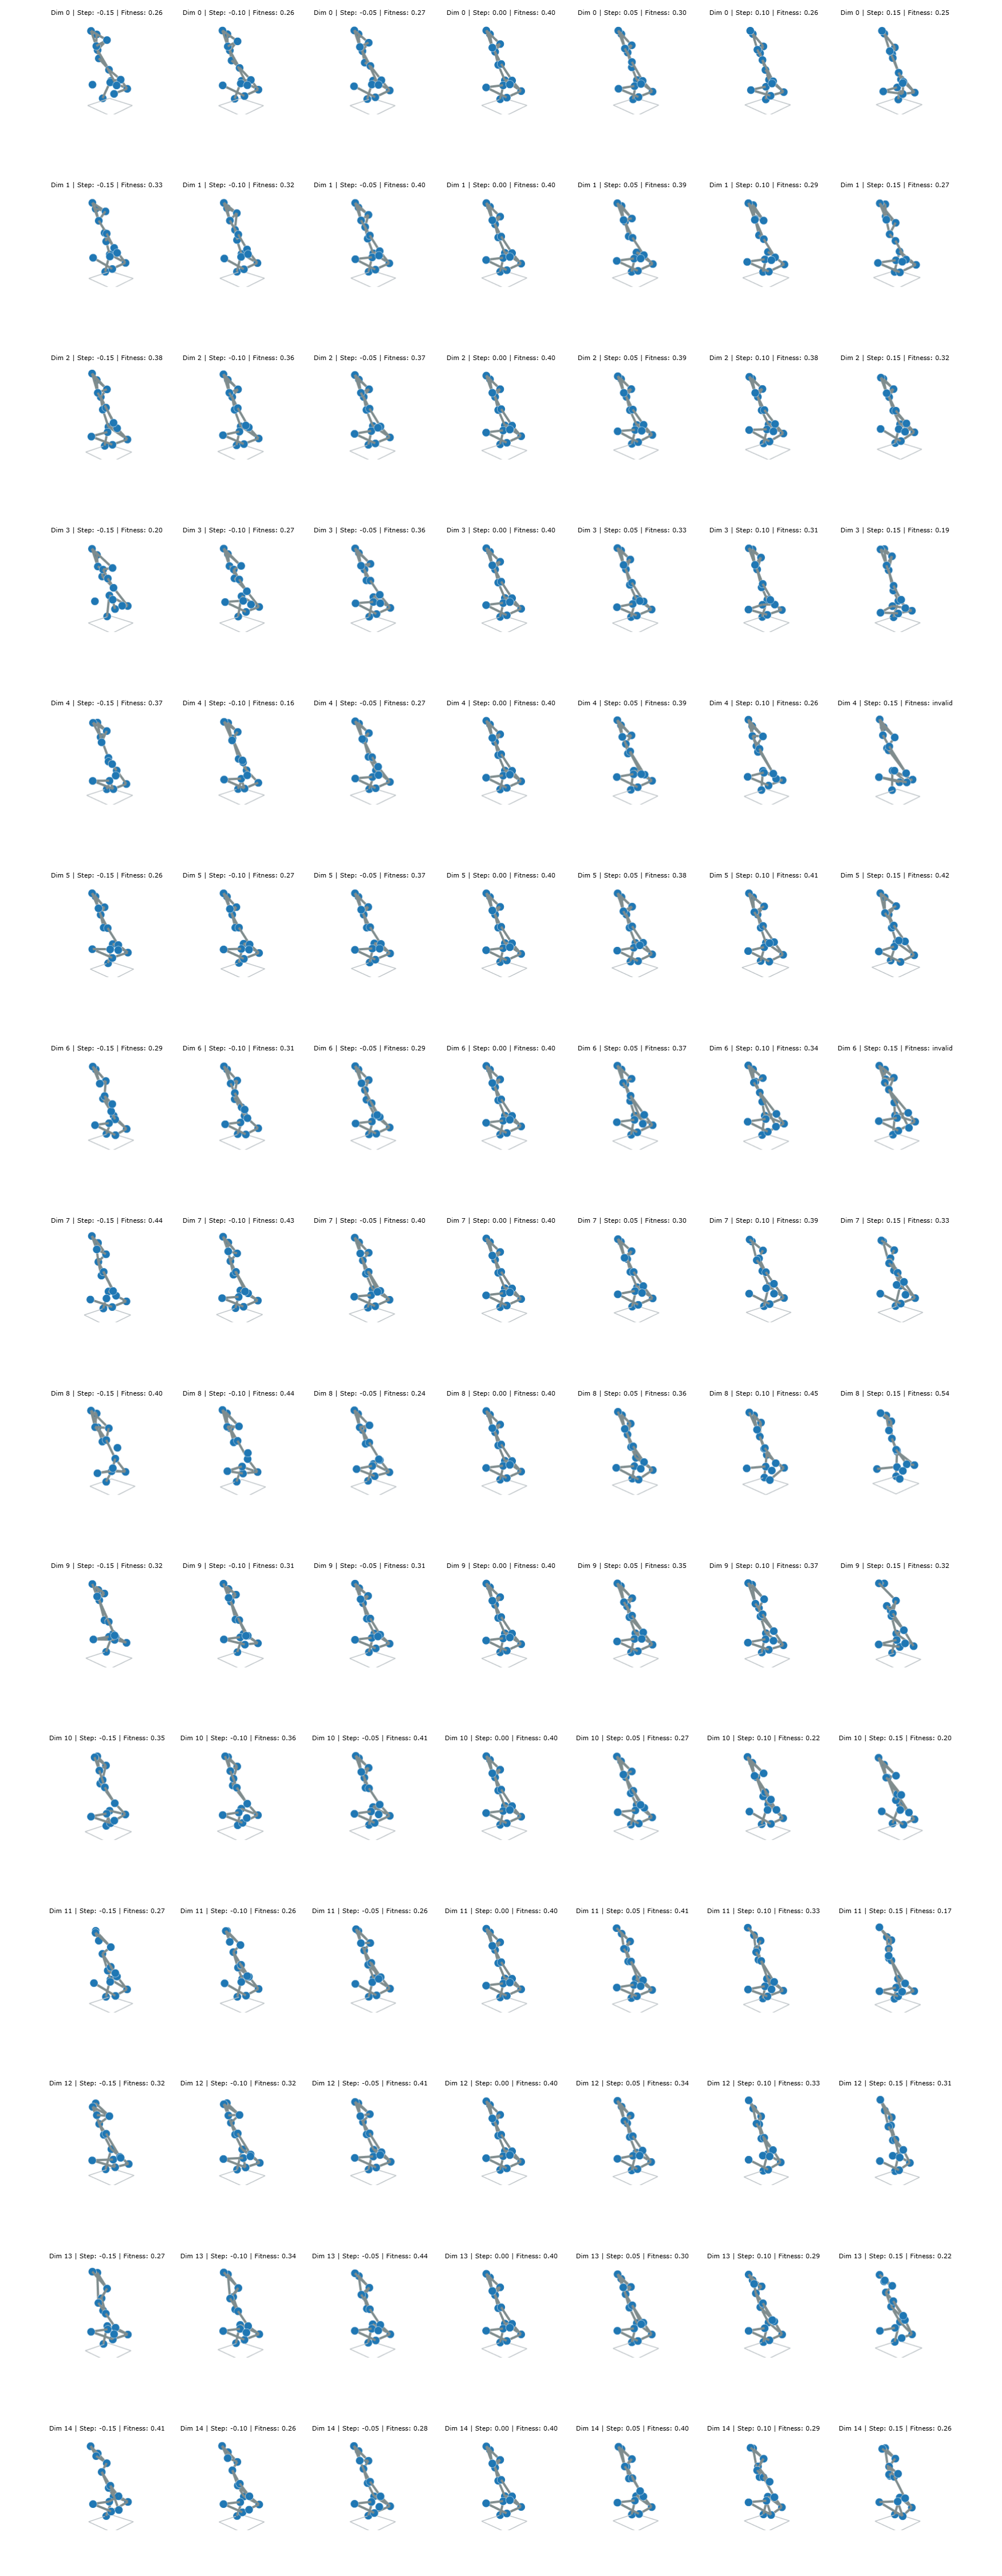

In [15]:
visualize_latent_grid_search_plotly(chosen_vector, 0.05, 3)

# Badanie zdegenerowanej przestrzeni

TODO: Na razie pomijamy

In [140]:
def visualize_degenerate_individuals(
		lower_percentile=85, upper_percentile=98,
		title="Osobniki Zdegenerowane (Outliery)"
):
	centroid = np.mean(z_matrix, axis=0)
	distances = np.linalg.norm(z_matrix - centroid, axis=1)

	d_min = np.percentile(distances, lower_percentile)
	d_max = np.percentile(distances, upper_percentile)
	deg_mask = (distances >= d_min) & (distances <= d_max)
	norm_mask = ~deg_mask

	z_pca = pca3d.transform(z_matrix)
	exp_var = pca3d.explained_variance_ratio_ * 100

	fig = go.Figure()

	fig.add_trace(go.Scatter3d(
		x=z_pca[norm_mask, 0], y=z_pca[norm_mask, 1], z=z_pca[norm_mask, 2],
		mode='markers',
		marker=dict(
			size=viz_cfg['marker_size'],
			color=distances[norm_mask],
			colorscale='Viridis',
			opacity=0.35,
			colorbar=dict(
				title=dict(
					text="Distance to centroid",
					font=dict(color='black')
				),
				tickfont=dict(color='black')
			)
		),
		name='Populacja standardowa'
	))

	fig.add_trace(go.Scatter3d(
		x=z_pca[deg_mask, 0], y=z_pca[deg_mask, 1], z=z_pca[deg_mask, 2],
		mode='markers',
		marker=cross_marker_dict,
		name=f'Zdegenerowane ({lower_percentile}-{upper_percentile}%)'
	))

	fig.update_layout(
		width=900,
		height=800,
		title=dict(
			text=f"{title} (Wyjaśniona wariancja: {sum(exp_var):.1f}%)",
			x=0.5,
			font=dict(size=16, color='black')
		),
		scene=dict(
			aspectmode='cube',
			camera=dict(eye=viz_cfg['camera_eye']),
			xaxis=dict(
				title=dict(text=f'PC1 ({exp_var[0]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='black')
			),
			yaxis=dict(
				title=dict(text=f'PC2 ({exp_var[1]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='black')
			),
			zaxis=dict(
				title=dict(text=f'PC3 ({exp_var[2]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='black')
			)
		),
		paper_bgcolor=viz_cfg['paper_bgcolor'],
		plot_bgcolor=viz_cfg['plot_bgcolor'],
		margin=dict(l=0, r=0, b=0, t=50),
		legend=vis_legend_dict
	)

	fig.show()

	return z_matrix[deg_mask]

In [141]:
def visualize_degenerate_phenotypes(
		degenerate_vectors,
		cols=4,
		max_individuals=16,
		output_pdf="degenerate_phenotypes.pdf"
):
	n_samples = int(min(len(degenerate_vectors), max_individuals))
	if n_samples == 0:
		print("Brak osobników do wyświetlenia.")
		return

	cols = int(min(cols, n_samples))
	rows = int(math.ceil(n_samples / cols))

	subplot_titles = [f"Osobnik #{i + 1}" for i in range(n_samples)]

	fig = make_subplots(
		rows=rows,
		cols=cols,
		specs=[[{'type': 'scatter3d'} for _ in range(cols)] for _ in range(rows)],
		subplot_titles=subplot_titles
	)

	autoencoder.eval()

	with torch.no_grad():
		X_all, A_all = autoencoder.decode(torch.tensor(degenerate_vectors, dtype=torch.float32).squeeze_())

	for idx in range(n_samples):
		X = X_all[idx].numpy()
		A = A_all[idx].numpy()

		trace_edges, trace_nodes, trace_ground = get_plotly_traces(X, A)

		r = (idx // cols) + 1
		c = (idx % cols) + 1

		fig.add_trace(trace_edges, row=r, col=c)
		fig.add_trace(trace_nodes, row=r, col=c)
		fig.add_trace(trace_ground, row=r, col=c)

	apply_scene_3d_defaults(fig)
	apply_layout_defaults(fig, f"Fenotypy Zdegenerowanych Osobników (n={n_samples})", height=320 * rows,
						  width=300 * cols)
	fig.show()
	if output_pdf:
		fig.write_image(output_pdf)

In [142]:
deg_vectors = visualize_degenerate_individuals(
	lower_percentile=85,
	upper_percentile=98,
	title="Osobniki Zdegenerowane w Przestrzeni Ukrytej"
)

ValueError: 
    Invalid value of type 'builtins.tuple' received for the 'marker' property of scatter3d
        Received value: ({'size': 3, 'color': 'red', 'symbol': 'x', 'opacity': 0.9},)

    The 'marker' property is an instance of Marker
    that may be specified as:
      - An instance of :class:`plotly.graph_objs.scatter3d.Marker`
      - A dict of string/value properties that will be passed
        to the Marker constructor

In [139]:
visualize_degenerate_phenotypes(
	degenerate_vectors=deg_vectors,
	cols=4,
	max_individuals=12,
	output_pdf="degenerate_phenotypes.pdf"
)

# Wizualizacja 'strefy bezpiecznej'

In [40]:
def generate_fibonacci_sphere(num_samples, radius=1.0):
	points = np.empty((num_samples, 3), dtype=np.float32)
	phi = (1 + np.sqrt(5)) / 2
	indices = np.arange(num_samples, dtype=np.float32)
	y = 1.0 - (indices / (num_samples - 1)) * 2.0
	r_at_y = np.sqrt(1.0 - y * y)
	theta = 2.0 * np.pi * indices / phi

	points[:, 0] = np.cos(theta) * r_at_y * radius
	points[:, 1] = y * radius
	points[:, 2] = np.sin(theta) * r_at_y * radius

	return points


def sample_hypersphere_surface(center, radius, num_samples):
	dim = center.shape[0]
	gaussian_directions = np.random.normal(0, 1, size=(num_samples, dim)).astype(np.float32)
	norms = np.linalg.norm(gaussian_directions, axis=1, keepdims=True)
	unit_directions = gaussian_directions / norms
	return (center + radius * unit_directions).astype(np.float32)


def explore_safe_zone(
		base_vector,
		radius,
		num_samples,
		mode,  # 'hypersphere' lub 'sphere'
		title,
		save_filename
):
	latent_dim = base_vector.shape[0]
	base_pca = pca3d.transform(base_vector.reshape(1, -1))[0].astype(np.float32)

	if mode == 'hypersphere':
		samples_z = sample_hypersphere_surface(
			center=base_vector,
			radius=radius,
			num_samples=num_samples
		).astype(np.float32)
		samples_pca = pca3d.transform(samples_z).astype(np.float32)
		mode_label = f"Hypersphere ({latent_dim}D)"
	else:
		sphere_offsets = generate_fibonacci_sphere(num_samples=num_samples, radius=radius)
		samples_pca = (base_pca + sphere_offsets).astype(np.float32)
		samples_z = pca3d.inverse_transform(samples_pca).astype(np.float32)
		mode_label = "Fibonacci Sphere (3D PCA)"

	base_fitness_tuple, _, _, _, _ = evaluator(base_vector)
	base_fitness = float(base_fitness_tuple[0])

	is_valid = np.zeros(num_samples, dtype=bool)
	fitnesses = np.zeros(num_samples, dtype=np.float32)

	for i in range(num_samples):
		fitness_tuple, _, is_valid_ind, _, _ = evaluator(samples_z[i])
		is_valid[i] = bool(is_valid_ind)
		fitnesses[i] = float(fitness_tuple[0])

	better_idx = np.where(is_valid & (fitnesses > base_fitness))[0]
	worse_valid_idx = np.where(is_valid & (fitnesses <= base_fitness))[0]
	invalid_idx = np.where(~is_valid)[0]

	exp_var = pca3d.explained_variance_ratio_ * 100
	fig = go.Figure()

	if len(better_idx) > 0:
		better_labels = [f"{fitnesses[i]:.2f}" for i in better_idx]
		fig.add_trace(go.Scatter3d(
			x=samples_pca[better_idx, 0],
			y=samples_pca[better_idx, 1],
			z=samples_pca[better_idx, 2],
			mode='markers+text',
			marker=dict(size=6, color='#2ecc71', opacity=0.9),
			text=better_labels,
			textposition='top center',
			textfont=dict(size=10, color='green'),
			name=f'Better ({len(better_idx)})',
			hovertemplate="<b>Better (Valid)</b><br>Fitness: %{text}<br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>"
		))

	if len(worse_valid_idx) > 0:
		worse_labels = [f"{fitnesses[i]:.2f}" for i in worse_valid_idx]
		fig.add_trace(go.Scatter3d(
			x=samples_pca[worse_valid_idx, 0],
			y=samples_pca[worse_valid_idx, 1],
			z=samples_pca[worse_valid_idx, 2],
			mode='markers+text',
			marker=dict(size=5, color='#e67e22', opacity=0.9),
			text=worse_labels,
			textposition='top center',
			textfont=dict(size=10, color='orange'),
			name=f'Worse ({len(worse_valid_idx)})',
			hovertemplate="<b>Worse</b><br>Fitness: %{text}<br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>"
		))

	if len(invalid_idx) > 0:
		marker_cfg = cross_marker_dict[0] if isinstance(cross_marker_dict, tuple) else cross_marker_dict
		fig.add_trace(go.Scatter3d(
			x=samples_pca[invalid_idx, 0],
			y=samples_pca[invalid_idx, 1],
			z=samples_pca[invalid_idx, 2],
			mode='markers',
			marker=marker_cfg,
			name=f'Invalid ({len(invalid_idx)})',
			hovertemplate="<b>Invalid</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>"
		))

	fig.add_trace(go.Scatter3d(
		x=[base_pca[0]],
		y=[base_pca[1]],
		z=[base_pca[2]],
		mode='markers+text',
		marker=dict(size=6, color='pink', symbol='diamond', line=dict(color='black', width=1.5)),
		text=[f"Base: {base_fitness:.2f}"],
		textposition='bottom center',
		textfont=dict(size=8, color='pink'),
		name='Base',
		hovertemplate=f"<b>Base</b><br>Fitness: {base_fitness:.2f}<extra></extra>"
	))

	chart_title = title if title else f"Safe Zone Exploration [{mode_label}]"
	fig.update_layout(
		width=900,
		height=800,
		title=dict(
			text=f"{chart_title} | Radius: {radius} | n={num_samples} | Base fitness={base_fitness:.2f}",
			x=0.5,
			font=dict(size=16, color="black")
		),
		scene=dict(
			aspectmode='cube',
			xaxis=dict(
				title=dict(text=f'PC1 ({exp_var[0]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='black')
			),
			yaxis=dict(
				title=dict(text=f'PC2 ({exp_var[1]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='black')
			),
			zaxis=dict(
				title=dict(text=f'PC3 ({exp_var[2]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='black')
			),
			camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
		),
		margin=dict(l=0, r=0, b=0, t=50),
		legend=vis_legend_dict,
		paper_bgcolor=viz_cfg['paper_bgcolor'],
		plot_bgcolor=viz_cfg['plot_bgcolor']
	)
	save_for_paper(fig, save_filename, config_vis['output_dir'], 'png', 2)
	fig.show()

## Wersja ze sferą PCA

In [41]:
explore_safe_zone(
	base_vector=chosen_vector,
	radius=1.0,
	num_samples=150,
	mode='sphere',
	title="Neighborhood, PCA",
	save_filename="neighborhood_pca_sphere_1"
)

In [33]:
explore_safe_zone(
	base_vector=chosen_vector,
	radius=0.1,
	num_samples=150,
	mode='sphere',
	title="Neighborhood, PCA",
	save_filename="neighborhood_pca_sphere_01"
)

In [34]:
explore_safe_zone(
	base_vector=chosen_vector,
	radius=0.01,
	num_samples=150,
	mode='sphere',
	title="Neighborhood, PCA",
	save_filename="neighborhood_pca_sphere_001"
)

## Wersja z hipersferą

In [39]:
explore_safe_zone(
	base_vector=chosen_vector,
	radius=0.1,
	num_samples=150,
	mode='hypersphere',
	title="Neighborhood, hypersphere",
	save_filename="neighborhood_hypersphere_01")

(array([[-0.5408709 , -0.30798268, -1.0515709 , ..., -0.03685881,
         -0.24476026,  0.46153116],
        [-0.49256983, -0.31700924, -0.9822761 , ..., -0.09237589,
         -0.24671768,  0.39477986],
        [-0.5371711 , -0.32580763, -1.0135572 , ..., -0.03124501,
         -0.28393722,  0.45041627],
        ...,
        [-0.54140526, -0.2864919 , -1.0249603 , ..., -0.01551864,
         -0.30626187,  0.41107374],
        [-0.5285925 , -0.3027709 , -1.0430692 , ..., -0.04812435,
         -0.2642277 ,  0.41846597],
        [-0.5333693 , -0.3021984 , -1.068188  , ..., -0.06736386,
         -0.25616887,  0.38182303]], shape=(150, 15), dtype=float32),
 array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True, 

# Wizualizacja ścieżki pętli encode -> decode

In [66]:
def visualize_latent_journeys_interactive(
		trajectories_list,
		fitnesses_list,
		title,
		save_filename
):
	bg_pca = pca3d.transform(z_matrix)
	exp_var = pca3d.explained_variance_ratio_ * 100

	max_bg = 5000
	if bg_pca.shape[0] > max_bg:
		sub_idx = np.random.choice(bg_pca.shape[0], max_bg, replace=False)
		bg_pca_sub = bg_pca[sub_idx]
	else:
		bg_pca_sub = bg_pca

	fig = go.Figure()

	fig.add_trace(go.Scatter3d(
		x=bg_pca_sub[:, 0], y=bg_pca_sub[:, 1], z=bg_pca_sub[:, 2],
		mode='markers',
		marker=dict(size=3, color='lightgray', opacity=0.22),
		name='Population',
		hoverinfo='none'
	))

	n_paths = len(trajectories_list)
	palette = [f"hsl({int(h)}, 75%, 50%)" for h in np.linspace(0, 360, n_paths, endpoint=False)]

	for idx, (trajectory, fitness_history) in enumerate(zip(trajectories_list, fitnesses_list)):
		traj_array = np.vstack([
			v.numpy().flatten() if torch.is_tensor(v) else np.asarray(v).flatten()
			for v in trajectory
		])

		traj_pca = pca3d.transform(traj_array)
		path_color = palette[idx]

		# labels = [
		# 	f"{step} | invalid" if fit < 0 else f"{step} | {fit:.2f}"
		# 	for step, fit in enumerate(fitness_history)
		# ]
		labels = [
			"" for _ in enumerate(fitness_history)
		]

		fig.add_trace(go.Scatter3d(
			x=traj_pca[:, 0],
			y=traj_pca[:, 1],
			z=traj_pca[:, 2],
			mode='lines+markers+text',
			marker=dict(size=2, color=path_color),
			line=dict(color=path_color, width=4),
			text=labels,
			textposition='top center',
			textfont=dict(color='black', size=10),
			hovertemplate=f"<b>Ścieżka {idx + 1}</b><br>%{{text}}<extra></extra>",
			name=f'Individual {idx + 1}'
		))

		fig.add_trace(go.Scatter3d(
			x=[traj_pca[0, 0]], y=[traj_pca[0, 1]], z=[traj_pca[0, 2]],
			mode='markers',
			marker=dict(size=2, color='pink', symbol='diamond', line=dict(color='black', width=1)),
			showlegend=False,
			hoverinfo='skip'
		))

		fig.add_trace(go.Scatter3d(
			x=[traj_pca[-1, 0]], y=[traj_pca[-1, 1]], z=[traj_pca[-1, 2]],
			mode='markers',
			marker=dict(size=2, color=path_color, symbol='square', line=dict(color='black', width=1)),
			showlegend=False,
			hoverinfo='skip'
		))

	fig.update_layout(
		width=900,
		height=800,
		title=dict(
			text=f"{title} (Variance: {sum(exp_var):.1f}%)",
			x=0.5,
			font=dict(size=16, color='black')
		),
		scene=dict(
			aspectmode='cube',
			camera=dict(eye=viz_cfg.get('camera_eye', dict(x=1.3, y=1.3, z=1.0))),
			xaxis=dict(
				title=dict(text=f'PC1 ({exp_var[0]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='white')
			),
			yaxis=dict(
				title=dict(text=f'PC2 ({exp_var[1]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='white')
			),
			zaxis=dict(
				title=dict(text=f'PC3 ({exp_var[2]:.1f}%)', font=dict(color='black')),
				tickfont=dict(color='white')
			)
		),
		margin=dict(l=0, r=0, b=0, t=50),
		legend=vis_legend_dict,
		paper_bgcolor=viz_cfg['paper_bgcolor'],
		plot_bgcolor=viz_cfg['plot_bgcolor']
	)

	if save_filename:
		save_for_paper(fig, save_filename, config_vis['output_dir'], "png", config_vis['scale'])

	fig.show()

In [68]:
radius = 0.1
num_samples = 15
steps = 10
mode = 'hypersphere'  # 'sphere' (Fibonacci w 3D PCA) lub 'hypersphere' (w pełnej przestrzeni Z)

base_z = chosen_vector.detach().cpu().numpy().flatten() if torch.is_tensor(chosen_vector) else np.asarray(
	chosen_vector).flatten()

if mode == 'hypersphere':
	sphere_points = sample_hypersphere_surface(center=base_z, radius=radius, num_samples=num_samples).astype(np.float32)
else:
	base_pca = pca3d.transform(base_z.reshape(1, -1))[0].astype(np.float32)
	offsets = generate_fibonacci_sphere(num_samples=num_samples, radius=radius)
	sphere_pca = (base_pca + offsets).astype(np.float32)
	sphere_points = pca3d.inverse_transform(sphere_pca).astype(np.float32)

starting_vectors = np.vstack([base_z.reshape(1, -1), sphere_points])

trajectories_list = []
fitnesses_list = []

autoencoder.eval()
with torch.no_grad():
	for start_z in starting_vectors:
		trajectory_latent_vector = []
		fitness_history = []

		current_z = torch.tensor(start_z, dtype=torch.float32).unsqueeze(0)

		for step in range(steps):
			z_np = current_z.squeeze(0).cpu().numpy().astype(np.float32)

			fitness_tuple, _, is_valid_ind, _, _ = evaluator(z_np)
			fit_val = float(fitness_tuple[0]) if is_valid_ind else -1.0

			trajectory_latent_vector.append(z_np)
			fitness_history.append(fit_val)

			x_prime, a_probs = autoencoder.decode(current_z)
			current_z = autoencoder.encode(x_prime, a_probs)

		trajectories_list.append(trajectory_latent_vector)
		fitnesses_list.append(fitness_history)

visualize_latent_journeys_interactive(
	trajectories_list=trajectories_list,
	fitnesses_list=fitnesses_list,
	title="Encode decode loop path",
	save_filename="decode_encode_paths"
)

Zapisano: visualizations\decode_encode_paths.png (skala: 2x)
